In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('all_gbx_data_scaled.csv')

In [2]:
df.head()

,Unnamed: 0,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,...,S9_AN3,S9_AN4,S9_AN5,S9_AN6,S9_AN7,S9_AN8,S9_AN9,S9_AN10,S9_Speed,State
0,0,-0.369431,0.308187,-0.739451,-0.524874,1.357016,-0.473188,-0.390907,-0.154307,-1.000099,...,-0.499683,-0.378666,-0.404995,-0.727901,0.496784,0.356024,0.031759,0.669520,-1.000098,1
1,1,-0.634324,0.400644,-0.948071,-0.399580,1.214408,-0.506659,-0.471283,0.049007,-1.000099,...,-0.512779,-0.560482,-0.335487,-0.918227,-0.993746,0.271797,0.012803,0.404866,-1.000098,1
2,2,-0.963712,-0.086758,-1.066259,0.840456,-0.219053,-0.231510,-0.542011,0.135518,-1.000099,...,-0.265210,-0.799033,-0.204492,-0.305016,-0.103271,0.290064,-0.001463,0.417430,-1.000098,1
3,3,-1.224967,0.128320,-0.987579,0.658703,-0.120566,-0.329965,-0.601701,-0.003422,-1.000099,...,-0.128843,-1.428618,-0.082010,-0.655027,0.321801,0.071663,-0.006809,0.476999,-1.000098,1
4,4,-1.214718,0.628594,-0.768050,0.267174,-0.403716,-0.404129,-0.641022,0.021500,-1.000099,...,-0.264725,-1.625296,-0.249487,-0.599866,0.146248,0.050971,-0.000539,0.675822,-1.000098,1


In [3]:
# Isolation Forest model
features = df.columns
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
data_scaled = df_shuffled[features[1:-1]]

In [4]:
data_scaled.head()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,S10_AN3,...,S8_Speed,S9_AN3,S9_AN4,S9_AN5,S9_AN6,S9_AN7,S9_AN8,S9_AN9,S9_AN10,S9_Speed
0,1.862625,2.219735,-0.851453,0.733435,-2.655962,-0.103826,-1.957235,0.072824,1.002454,-0.232806,...,0.997134,0.468347,-1.464974,-0.778104,1.697512,-0.549572,-1.121066,-2.480293,1.330251,0.994301
1,0.293527,-0.187412,0.404146,-0.821256,-0.080298,-0.154078,-0.521863,0.971112,-1.000099,0.445555,...,-1.000098,0.066297,0.772995,1.336442,1.174220,0.486739,-0.907144,-0.469142,-0.652373,-1.000098
2,2.530712,0.191962,0.461574,0.958617,1.093366,1.582926,-0.028241,0.193455,0.996353,2.485597,...,1.004287,-0.168064,1.125510,-1.807854,-2.522122,1.865399,-1.429167,-1.746860,1.137645,1.004149
3,0.475379,-0.359171,0.087994,-1.248402,0.940273,-0.732297,-0.230083,0.384724,-1.000099,0.313044,...,-1.000099,-0.174148,0.580460,-0.296004,-1.542803,0.610471,-1.132272,-0.046617,0.613326,-1.000072
4,0.196689,1.940462,-0.220323,-0.183637,-0.765973,0.695495,-0.134687,-0.475197,-1.000099,-0.276298,...,-1.000099,0.351551,0.614714,1.122243,0.769602,0.541719,-0.452606,-0.623172,0.031962,-1.000098


In [5]:
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(data_scaled)

# Label: 1 = normal, -1 = anomaly
df['is_anomaly'] = df['anomaly'] == -1

# Print number of anomalies
print(f"Total anomalies found: {df['is_anomaly'].sum()}")

Total anomalies found: 240000


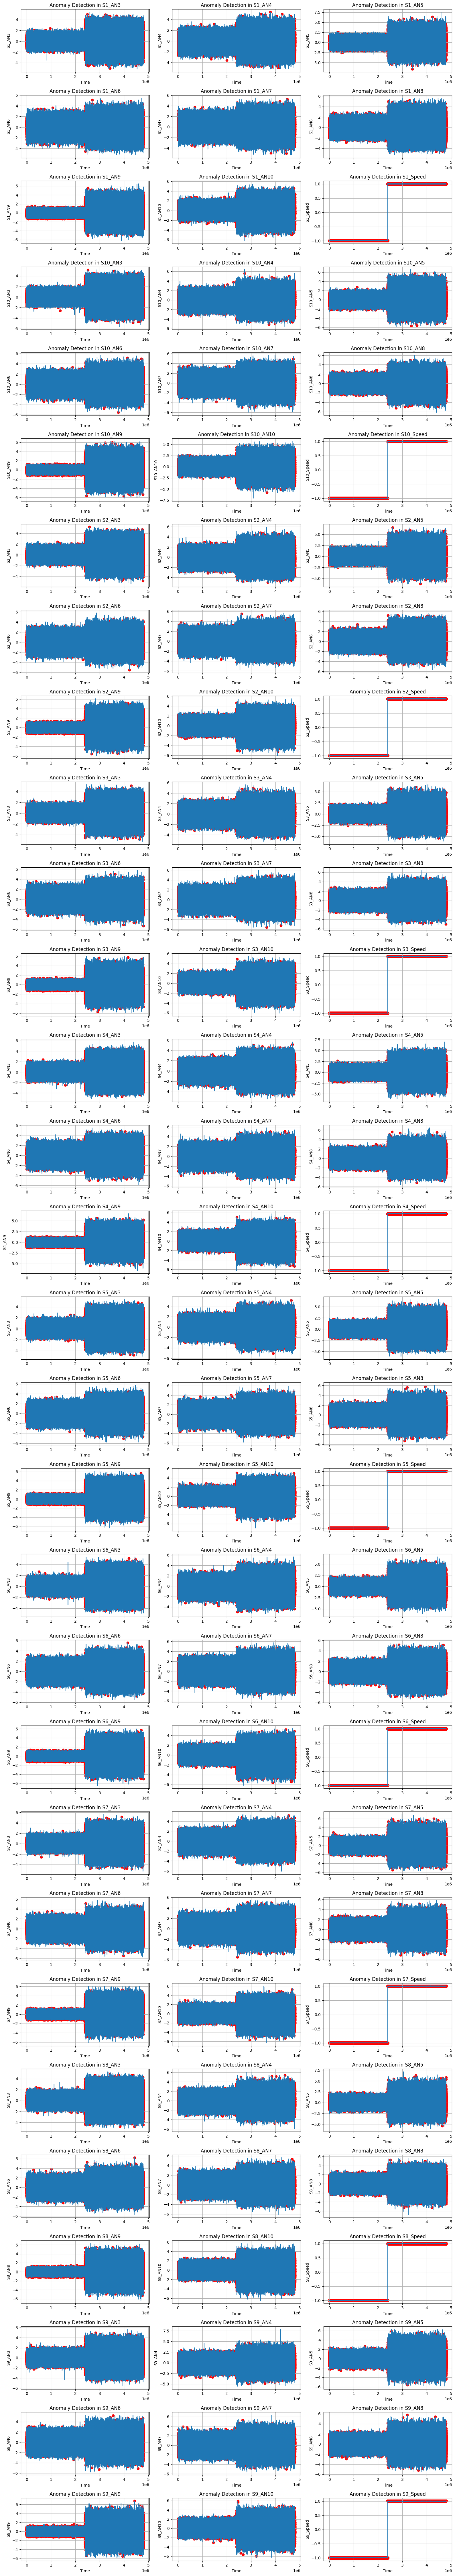

In [6]:
# Create 3x3 subplots
featuresToPlot = features[1:-1]
dataToPlot = data_scaled[featuresToPlot]
n_plots = len(featuresToPlot)
n_cols = 3
n_rows = -(-n_plots // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()  # flatten in case it's 2D

# Plot into each subplot
for i in range(0, len(featuresToPlot)):
    y = dataToPlot[featuresToPlot[i]]  # example variation
    axes[i].plot(df[featuresToPlot[i]], label='Sensor Data')
    axes[i].scatter(df[df['is_anomaly']].index, df[df['is_anomaly']][featuresToPlot[i]], color='red', label='Anomalies')
    axes[i].set_title(f'Anomaly Detection in {featuresToPlot[i]}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel(featuresToPlot[i])
    axes[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()